In [9]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

the determinant of the jacobian it has a computational cost: O(d^3) aiaiai!!

so when the determinant has decent computational cost? 
a possibile case is if the jacobian is a trinagular matrix 

in that case the determinant is just the product of the diagonal element of J:

det J = Prod J_{ii}

This is used in the Coupling Layers.

An easy example is the case where for one variable we have a translation:

x1 = z1,

x2 = z2 + t(z1)

it s invertible:

z1 = x1,

z2 = x2 -t(z1) = x2 -t(x1)

we can see that the jacobian is triangulat:
J = [1      ,     0  ][d t/ d z1 ,  1]

det J = 1 

so in this case the transformation is a lot limiting, it does not change the volume

In [10]:

def t(z1):
    return z1**2 

# forward: z -> x
def forward(z):
    z1, z2 = z[..., 0], z[..., 1]
    
    x1 = z1
    x2 = z2 + t(z1)
    
    return jnp.stack([x1, x2], axis=-1)

def inverse(x):
    x1, x2 = x[..., 0], x[..., 1]
    
    z1 = x1
    z2 = x2 - t(x1)
    
    return jnp.stack([z1, z2], axis=-1)

def log_det_jacobian(z):
    return jnp.zeros(z.shape[0])

In [11]:
def log_pz(z):
    return -0.5 * jnp.sum(z**2, axis=-1)

def log_px(x):
    z = inverse(x)
    return log_pz(z)  # no jacobian term since it's zero

sampling:

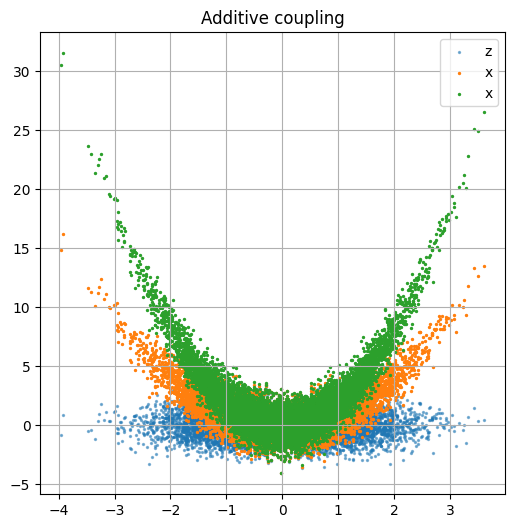

In [12]:
key = jax.random.PRNGKey(0)
z = jax.random.normal(key, (10000, 2))
x = forward(z)
y = forward(x)

plt.figure(figsize=(6,6))
plt.scatter(z[:,0], z[:,1], s=2, alpha=0.5, label='z')
plt.scatter(x[:,0], x[:,1], s=2, label='x')
plt.scatter(y[:,0], y[:,1], s=2, label='x')
plt.title("Additive coupling")
plt.legend()
plt.grid()
plt.show()